In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

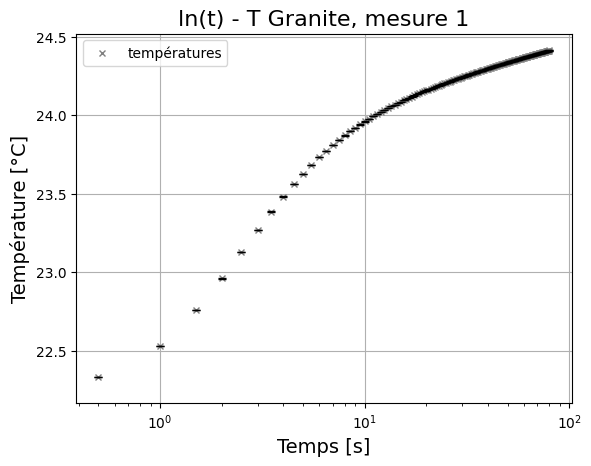

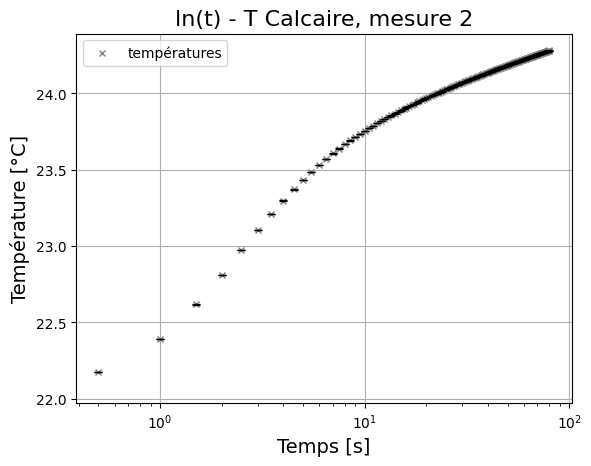

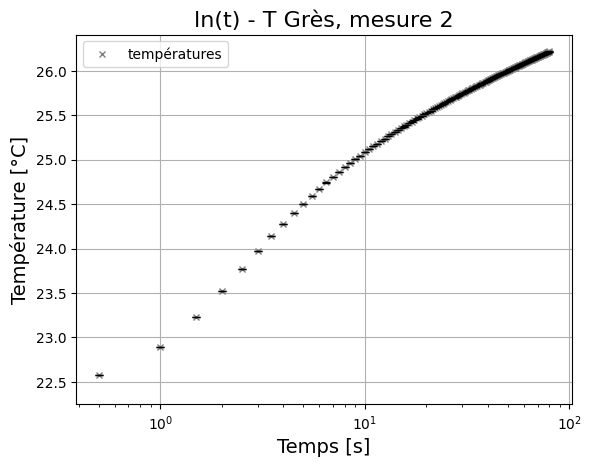

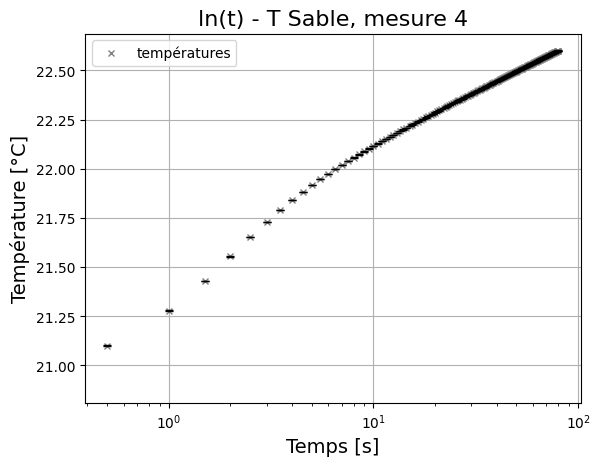

In [2]:
def plot_lnt_T(filename, titre):
    data = pd.read_excel("Datas/" + filename + ".xlsx")
    temperatures = data['T [oC]'].dropna()
    times = data['t [s]'].dropna()
    resistances = data['R [Ohm]'].dropna()

    # Graphique tempéreature en fonction de ln(t) complet
    fig, lnt_T = plt.subplots()
    lnt_T.plot(times,temperatures, marker='x', linestyle='none',linewidth=0,markersize=5, label = 'températures', color = 'gray')
    lnt_T.errorbar(times,temperatures,yerr=[0.001],c='k',linestyle='none',capsize=3)
    lnt_T.set_xlabel('Temps [s]',fontsize=14)
    lnt_T.set_ylabel('Température [°C]',fontsize=14)
    lnt_T.grid()
    lnt_T.set_xscale('log')
    lnt_T.legend()
    lnt_T.set_title(f"ln(t) - T {titre}",fontsize=16)

    plt.savefig("Figures/" + filename + ".jpg")

# Affichage
plot_lnt_T("granite1", "Granite, mesure 1")
plot_lnt_T("calcaire2", "Calcaire, mesure 2")
plot_lnt_T("gres2", "Grès, mesure 2")
plot_lnt_T("sable4", "Sable, mesure 4")

In [4]:
def compute_k(filename, upper_b, lower_b, q, ylim_bot, ylim_up):
# Affichage du graphique ln(t) - T et calcul de la droite de régression
    
    data = pd.read_excel("Datas/" + filename + ".xlsx")
    temperatures = data['T [oC]'].dropna()
    times = data['t [s]'].dropna()
    resistances = data['R [Ohm]'].dropna()

    # Bornage des données dans une zone précise
    times_borned = []
    temperatures_borned = []
    ln_times_borned = []

    for i in range(len(times)):
        if times[i] >= lower_b and times[i] <= upper_b:
            times_borned.append(times[i])
            temperatures_borned.append(temperatures[i])
            ln_times_borned.append(np.log(times[i]))

    # Graphique des données bornées
    fig, lnt_T = plt.subplots()
    lnt_T.plot(ln_times_borned, temperatures_borned, 'k', marker='x', linestyle='none', linewidth=0,markersize=5, label = 'températures')
    lnt_T.errorbar(ln_times_borned, temperatures_borned, yerr=[0.001], c='k', linestyle='none', capsize=3)
    lnt_T.set_xlabel('ln(t)',fontsize=14)
    lnt_T.set_ylabel('Température [°C]',fontsize=14)
    lnt_T.grid()
    lnt_T.set_ylim(ylim_bot, ylim_up)

    # Régression linéaire
    def function_for_fit(x,a,b): #fonction à ajouter, x est la variable, a et b les paramètres
        y = []
        for i in range(len(x)):
            y.append(a * x[i] + b)
            i+=1
        return y
    
    results_reg  = linregress(ln_times_borned, temperatures_borned)
    slope_reg = results_reg.slope
    intersect_reg = results_reg.intercept
    r_value = results_reg.rvalue
    p_value = results_reg.pvalue
    stderror_slope = results_reg.stderr
    stderror_intersect = results_reg.intercept_stderr
    
    # Affichage de la droite de régression
    lnt_T.plot(ln_times_borned, function_for_fit(ln_times_borned, slope_reg, intersect_reg),'b', label='droite de régression')
    lnt_T.set_title(f"Graphique ln(t) - T borné entre {lower_b}s et {upper_b}s",fontsize=16)
    plt.legend()

    # Affiche de l'équation dans le graphique
    x_pos = min(ln_times_borned)
    y_pos = max(temperatures_borned)
    lnt_T.text(x_pos, y_pos, rf'$y = {slope_reg:.3f}x + {intersect_reg:.3f}, R^2 = {r_value**2:.5f}$')

    plt.savefig(f"Figures/{filename}_reg_{upper_b}_{lower_b}.jpg")

# Calcul de la conductivité thermique et de son erreur
    slope_sigma = stderror_slope*np.sqrt(len(ln_times_borned))
    k = q/(4*np.pi)*1/slope_reg
    k_error = np.sqrt((0.01)**2+((2*slope_sigma)/slope_reg)**2)

    print(f"k = {k} +/- {k_error}")

k = 1.1424839820277684 +/- 0.17168615652225647


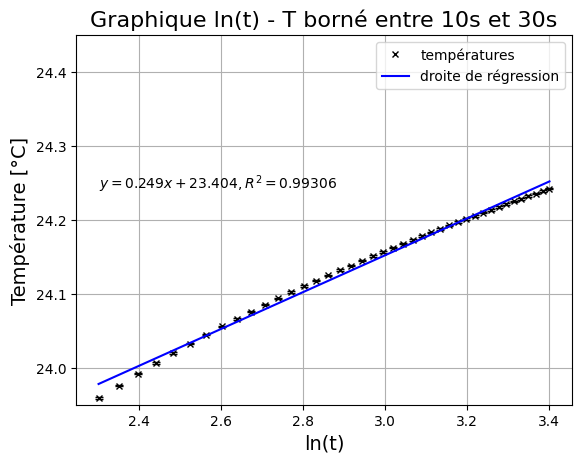

In [18]:
compute_k("granite1", 30, 10, 3.5813, 23.95, 24.45)

k = 1.5742936917873995 +/- 0.039865770778682585


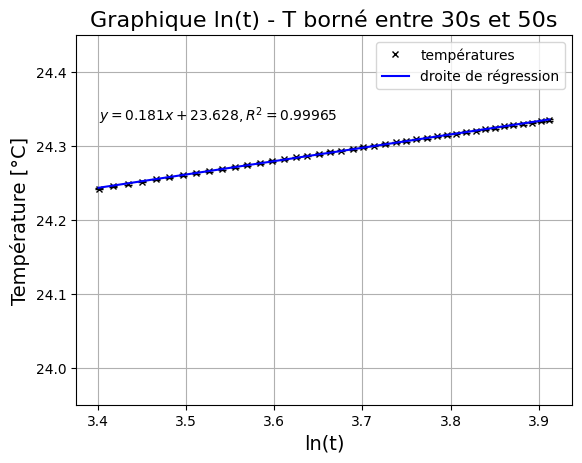

In [19]:
compute_k("granite1", 50, 30, 3.5813, 23.95, 24.45)

k = 1.7348682826569521 +/- 0.02608676026234472


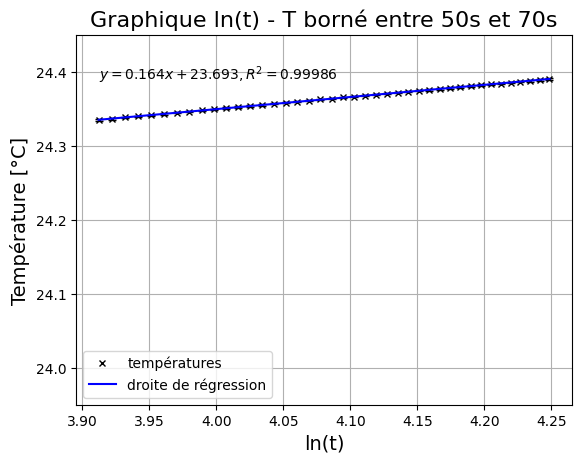

In [20]:
compute_k("granite1", 70, 50, 3.5813, 23.95, 24.45)

k = 0.9566292336778749 +/- 0.12064404288419112


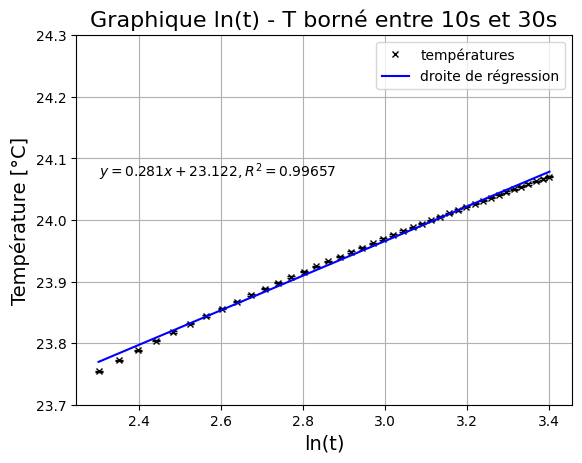

In [11]:
compute_k("calcaire2", 30, 10, 3.3790, 23.7, 24.3)

k = 1.2048286278840812 +/- 0.03014093974087934


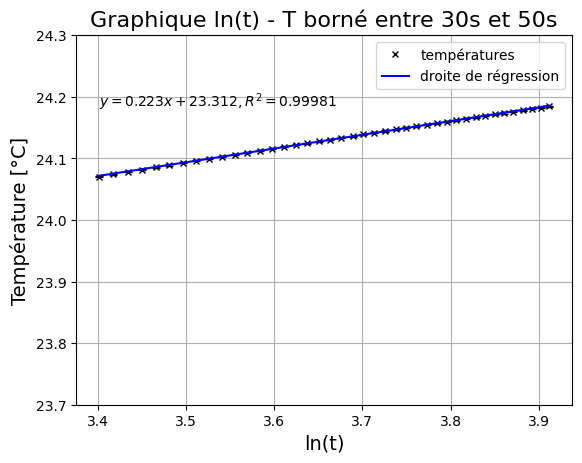

In [12]:
compute_k("calcaire2", 50, 30, 3.3790, 23.7, 24.3)

k = 1.3002219013717538 +/- 0.01861499138392288


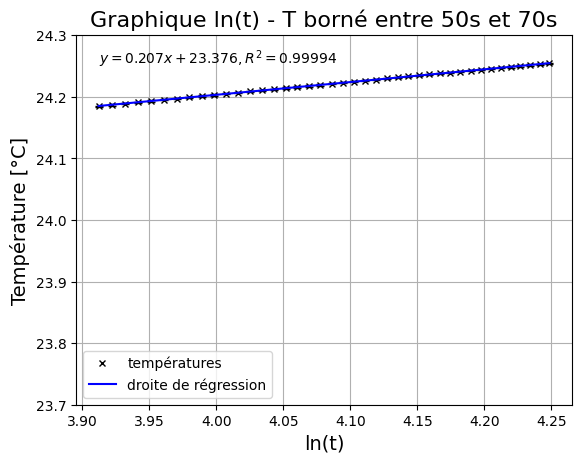

In [13]:
compute_k("calcaire2", 70, 50, 3.3790, 23.7, 24.3)

k = 0.6623812856950417 +/- 0.08839319891783774


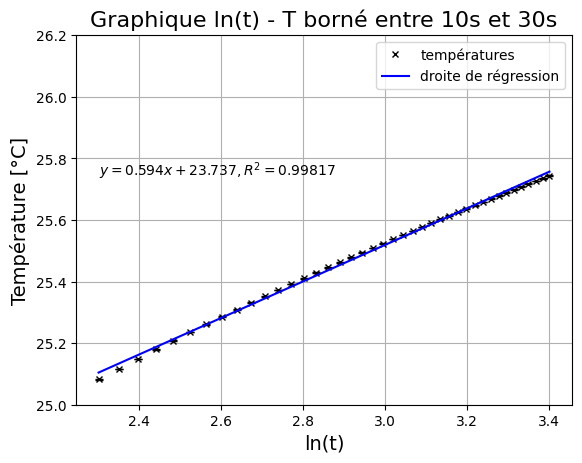

In [14]:
compute_k("gres2", 30, 10, 4.9430, 25, 26.2)

k = 0.791759592029423 +/- 0.026161528052176558


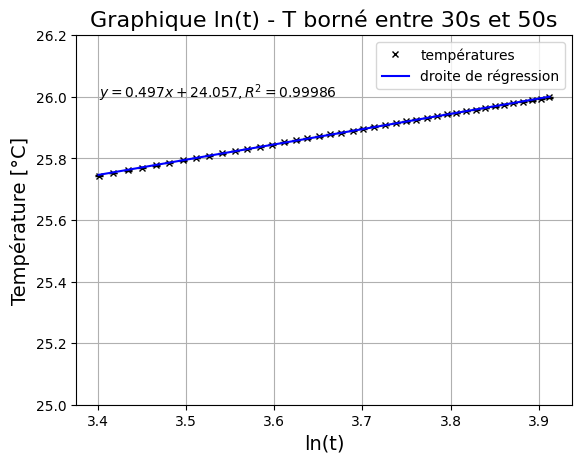

In [15]:
compute_k("gres2", 50, 30, 4.9430, 25, 26.2)

k = 0.8408036548299008 +/- 0.015810503083954264


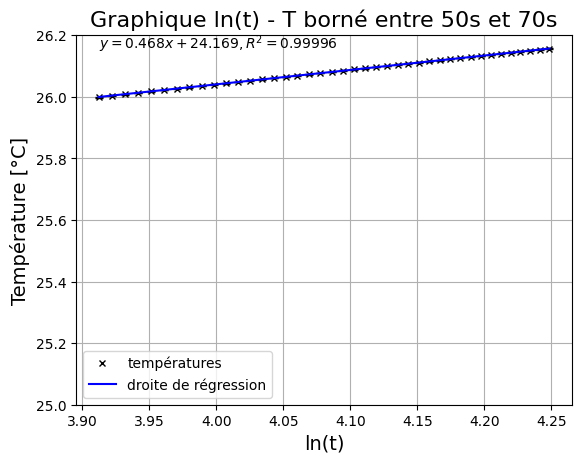

In [16]:
compute_k("gres2", 70, 50, 4.9430, 25, 26.2)

k = 2.344206387247005 +/- 0.0314622854688871


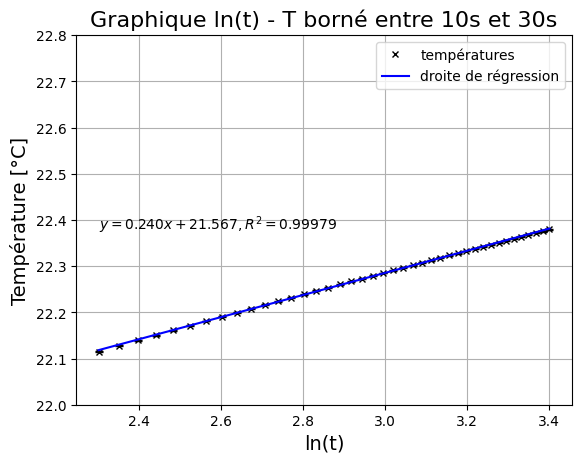

In [28]:
compute_k("sable4", 30, 10, 7.0569, 22, 22.8)

k = 2.4750782371850217 +/- 0.012968535907579055


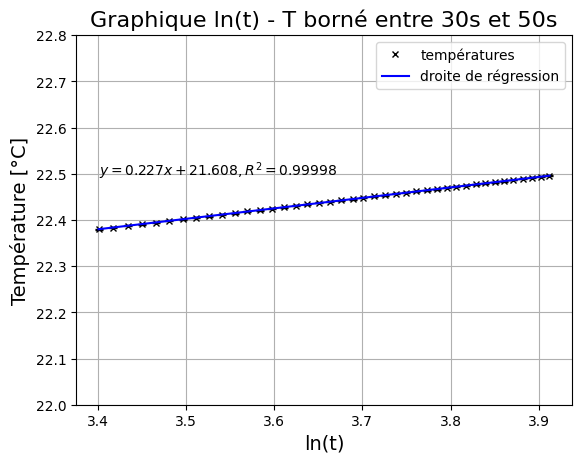

In [27]:
compute_k("sable4", 50, 30, 7.0569, 22, 22.8)

k = 2.5074457598135678 +/- 0.011732117489632677


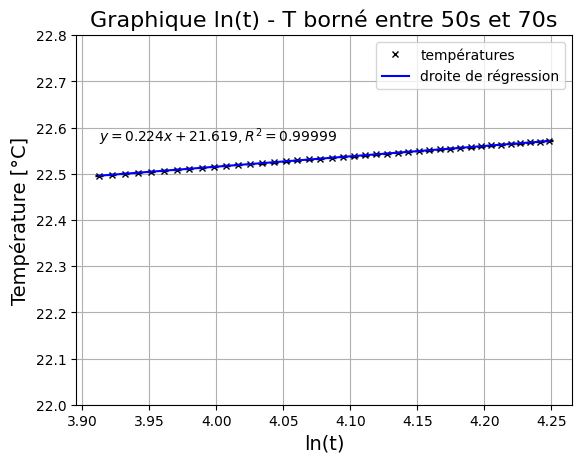

In [29]:
compute_k("sable4", 70, 50, 7.0569, 22, 22.8)